# Introducción

El acceso al crédito es un factor clave para el desarrollo del sector rural en Colombia. Este análisis utiliza datos de FinAgro para entender las tendencias de financiamiento en este sector y evaluar el impacto de la variación en el Índice Bancario de Referencia (IBR) en la cartera y los montos de crédito.

El dataset incluye información detallada sobre los créditos otorgados, como fecha, ubicación, intermediario financiero, tipo de productor, destino de los fondos y condiciones de financiamiento.

Los principales objetivos del análisis son:

* Explorar las tendencias de crédito en el sector rural, evaluando cómo se distribuyen los préstamos según características como tipo de productor, intermediario y línea de crédito.

* Analizar el impacto del IBR en la cartera y montos de financiamiento, identificando posibles correlaciones entre las tasas de interés y la asignación de crédito.

* Este estudio permitirá identificar patrones clave en la financiación rural y generar insights para la toma de decisiones en políticas de crédito y apoyo al sector agropecuario.

# Configuración e Imports

In [ ]:
!pip install squarify

In [ ]:
from IPython.display import clear_output

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import zipfile
import polars as pl
import squarify


In [ ]:
!gdown --fuzzy 'https://drive.google.com/file/d/1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi/view?usp=drive_link' --output dataset_finagro.csv

Downloading...
From (original): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi
From (redirected): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi&confirm=t&uuid=19ba8a41-8603-4048-8ba2-6ebf7925b342
To: /content/dataset_finagro.csv
100% 363M/363M [00:07<00:00, 45.7MB/s]


In [ ]:
df_pandas = pd.read_csv('dataset_finagro.csv', dtype = {'cod_municipio': str, 'cod_departamento': str})

In [ ]:
# Verificar categorías únicas primero
print(df_pandas['tipo_municipio'].unique())

['Intermedio' 'Ciudades y aglomeraciones' 'Rural disperso' 'Rural']


In [ ]:
# Reemplazo explícito
df_pandas['tipo_municipio'] = df_pandas['tipo_municipio'].replace({
    'Rural disperso': 'Rural',
    'Ciudades y aglomeraciones': 'Urbano',
    'Intermedio': 'Urbano'
})

In [ ]:
df_pandas.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new
0,2350103751,2023-01-05,5887,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253050,...,False,0,True,5,ANTIOQUIA,YARUMAL,Urbano,12.869376,17.917881,17.180
1,2350127280,2023-01-30,52083,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,900001,...,False,0,False,52,NARIÑO,BELÉN,Urbano,12.633951,17.861196,16.776
2,2302529983,2023-01-30,25126,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NaN,408011,...,False,0,True,25,CUNDINAMARCA,CAJICÁ,Urbano,12.547581,23.603404,21.379
3,2350117950,2023-01-20,68245,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253000,...,False,0,True,68,SANTANDER,EL GUACAMAYO,Rural,12.827946,17.875535,17.141
4,2350104346,2023-01-05,41006,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,347050,...,False,0,False,41,HUILA,ACEVEDO,Rural,12.869376,17.917881,17.180


In [ ]:
df_pandas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107953 entries, 0 to 1107952
Data columns (total 34 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   id_credito                    1107953 non-null  int64  
 1   fecha_credito                 1107953 non-null  object 
 2   cod_municipio                 1107953 non-null  object 
 3   tipo_cartera                  1107953 non-null  object 
 4   tipo_intermediario            1107953 non-null  object 
 5   tipo_productor                1107953 non-null  object 
 6   tipo_beneficiario             1107953 non-null  object 
 7   tipo_persona                  1107936 non-null  object 
 8   sexo                          1035723 non-null  object 
 9   cod_destino                   1107953 non-null  int64  
 10  linea_credito                 1107953 non-null  object 
 11  cadena                        1107953 non-null  object 
 12  eslabon_cadena              

# Naturaleza de las colocaciones

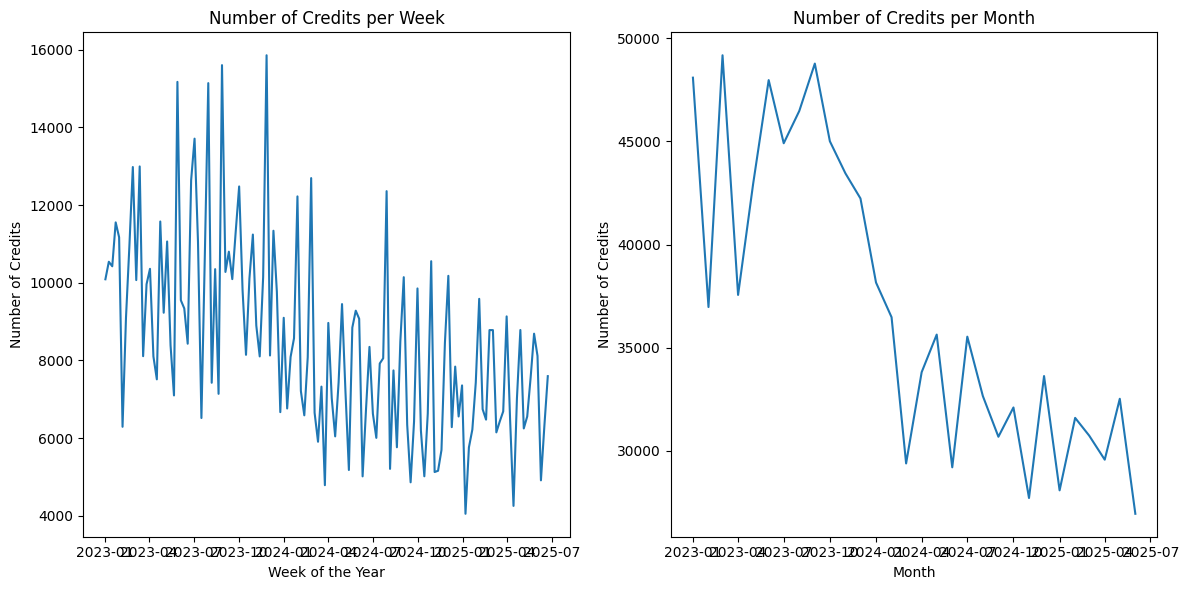

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['id_credito'].count()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['id_credito'].count()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Month')

plt.tight_layout()
plt.show()


In [ ]:
monthly_credits

,id_credito
month,
2023-01-01,48092
2023-02-01,36969
2023-03-01,49178
2023-04-01,37556
2023-05-01,42938
2023-06-01,47974
2023-07-01,44911
2023-08-01,46477
2023-09-01,48774


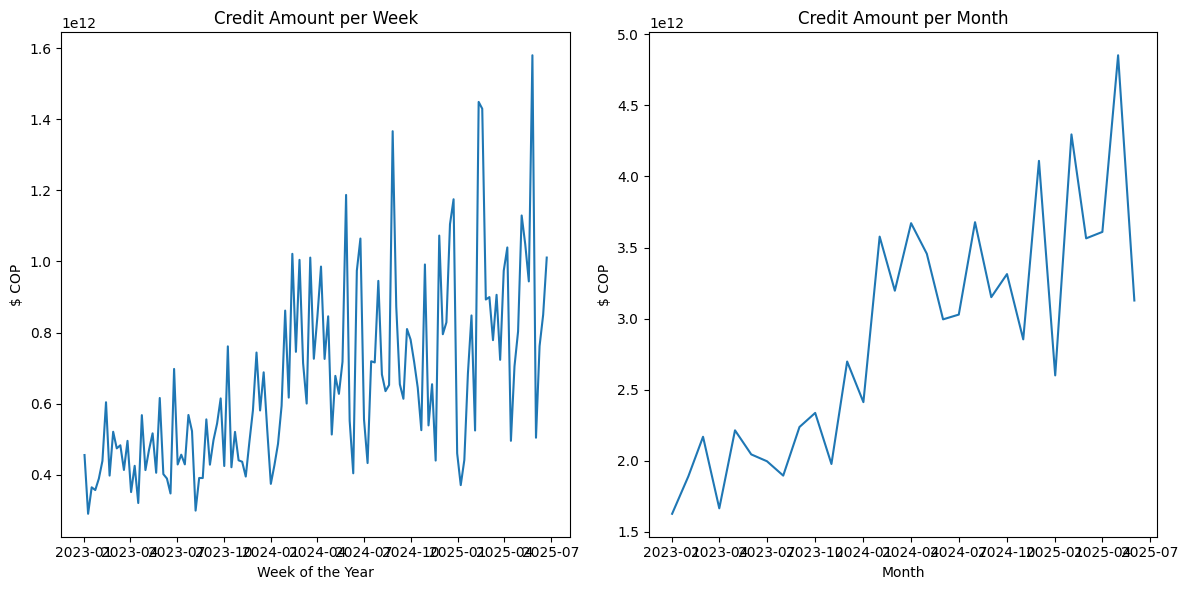

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].sum()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].sum()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Credit Amount per Month')

plt.tight_layout()
plt.show()


In [ ]:
monthly_credits

,valor_credito
month,
2023-01-01,1.627169e+12
2023-02-01,1.890889e+12
2023-03-01,2.168983e+12
2023-04-01,1.665582e+12
2023-05-01,2.214326e+12
2023-06-01,2.044924e+12
2023-07-01,1.996757e+12
2023-08-01,1.895781e+12
2023-09-01,2.237565e+12


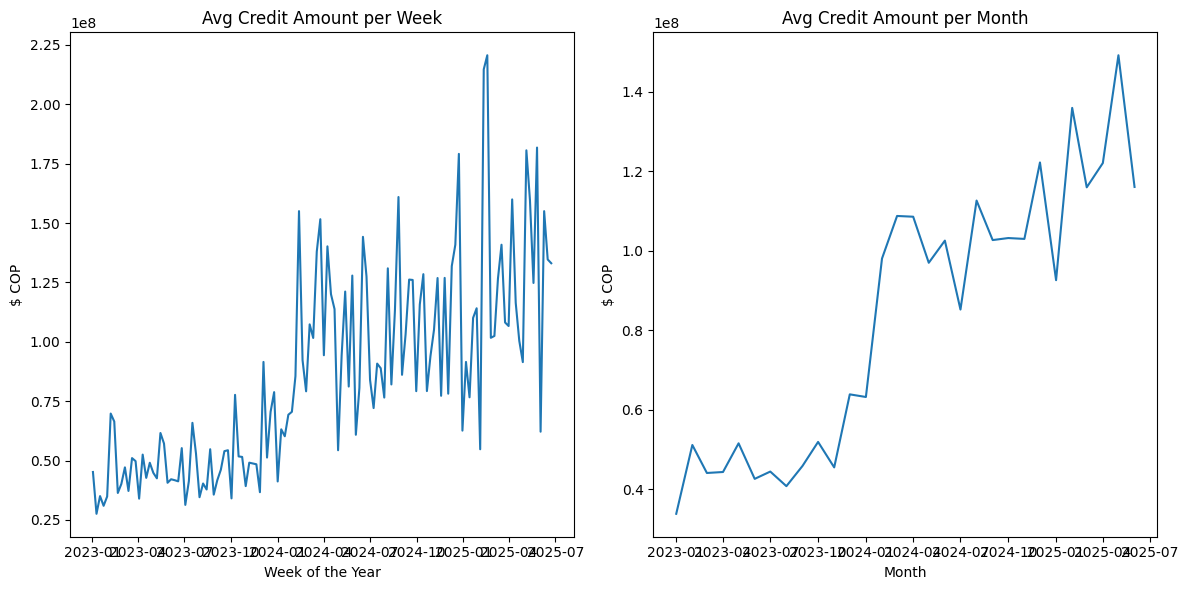

In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].mean()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].mean()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Month')

plt.tight_layout()
plt.show()


In [ ]:
df_pandas.columns

Index(['id_credito', 'fecha_credito', 'cod_municipio', 'tipo_cartera',
       'tipo_intermediario', 'tipo_productor', 'tipo_beneficiario',
       'tipo_persona', 'sexo', 'cod_destino', 'linea_credito', 'cadena',
       'eslabon_cadena', 'valor_credito', 'valor_inversion', 'plazo',
       'periodo_gracia', 'cuotas', 'cuotas_capital', 'tasa_indexacion',
       'periodicidad_tasa_indexacion', 'puntos_adicionales', 'garantia_fag',
       'nombre_programa', 'indicador_lec', 'valor_subsidio', 'nuevo',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'tasa_indexacion_valor', 'tasa_credito',
       'tasa_credito_new', 'week', 'month'],
      dtype='object')

In [ ]:
df_pandas = df_pandas[df_pandas['linea_credito']!='Normalización de Cartera']

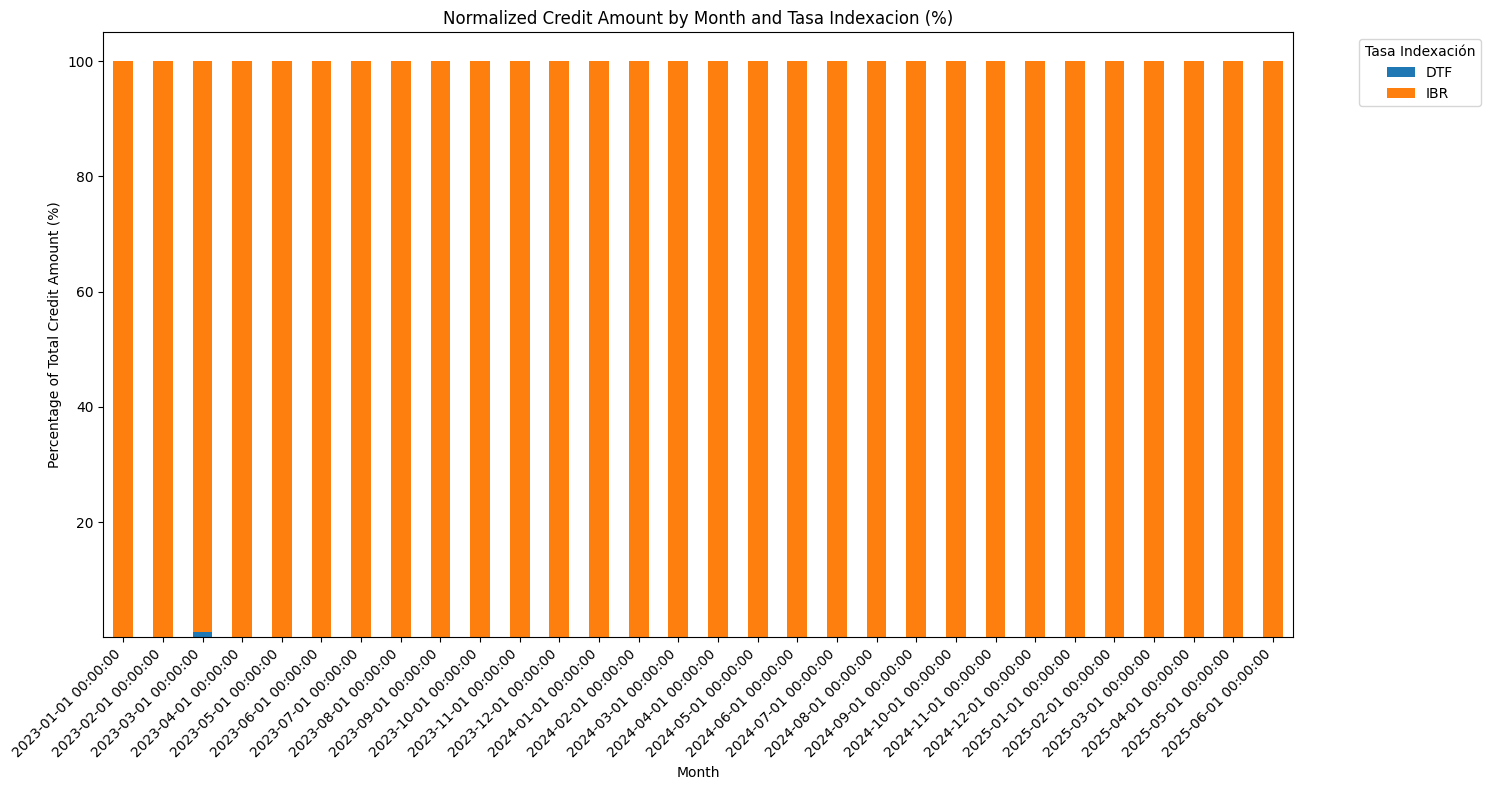

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tasa_indexacion'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tasa_indexacion', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tasa Indexacion (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tasa Indexación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

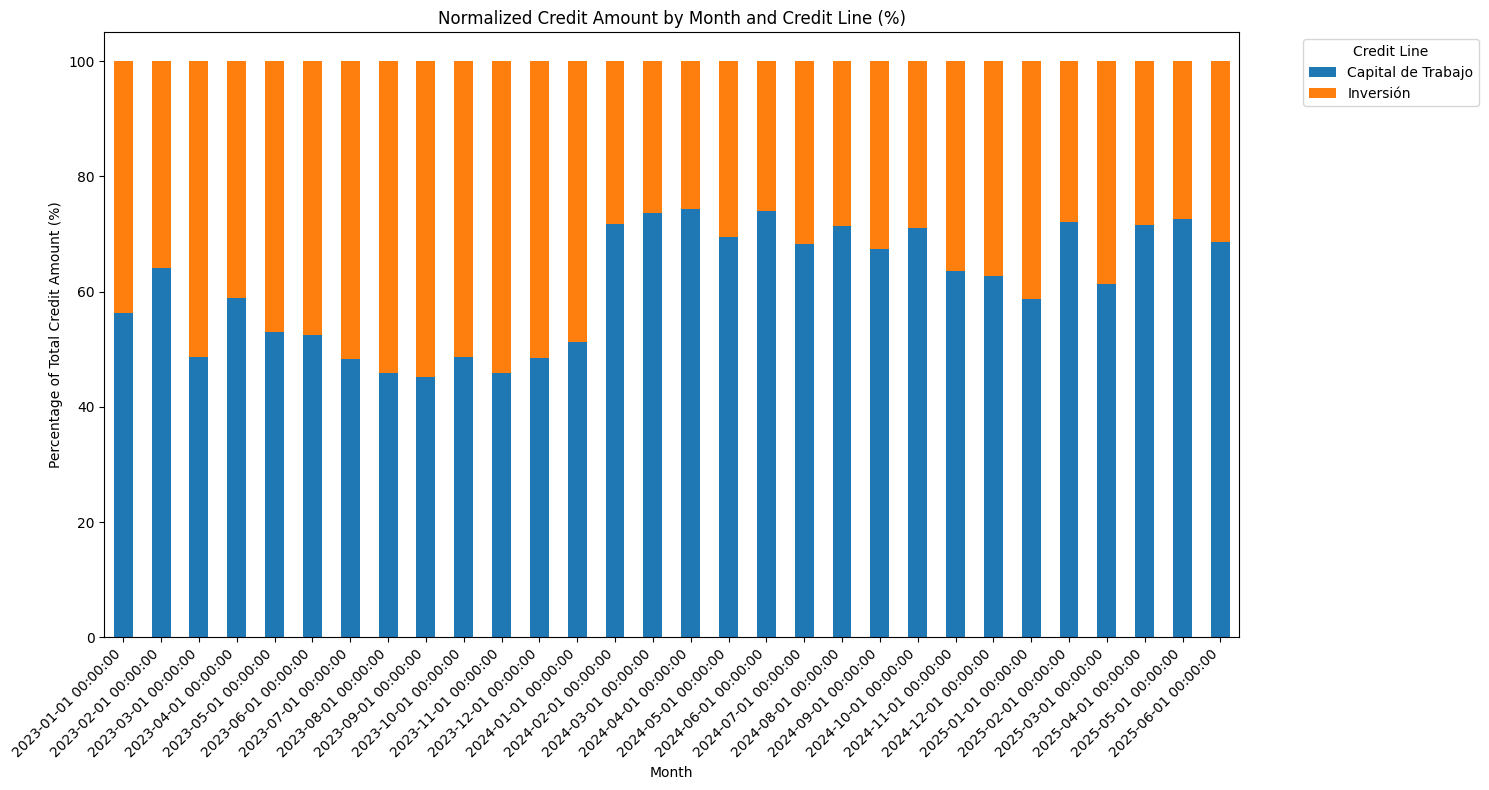

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'linea_credito'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='linea_credito', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Credit Line (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

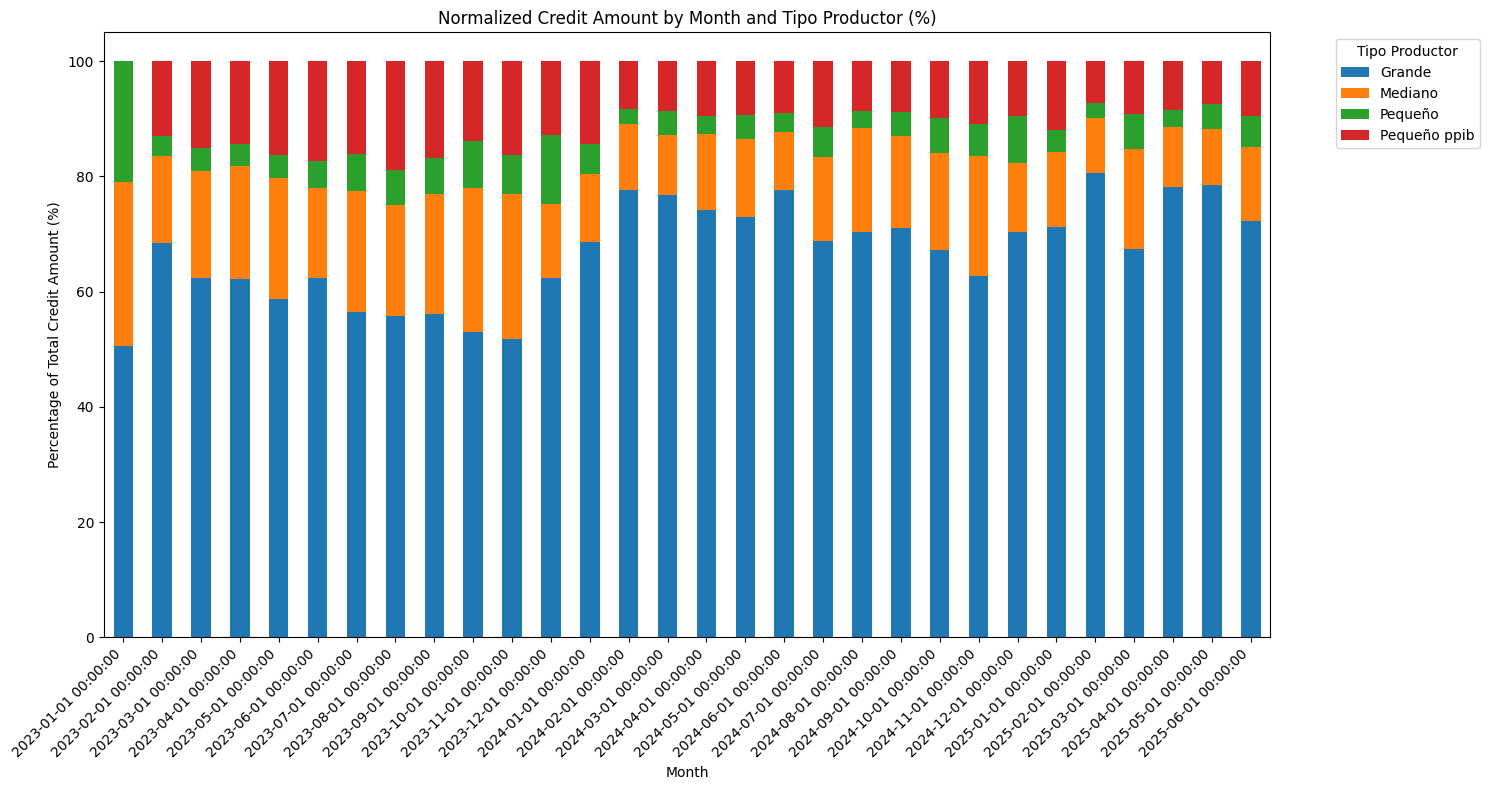

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_productor'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_productor', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Productor (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Productor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

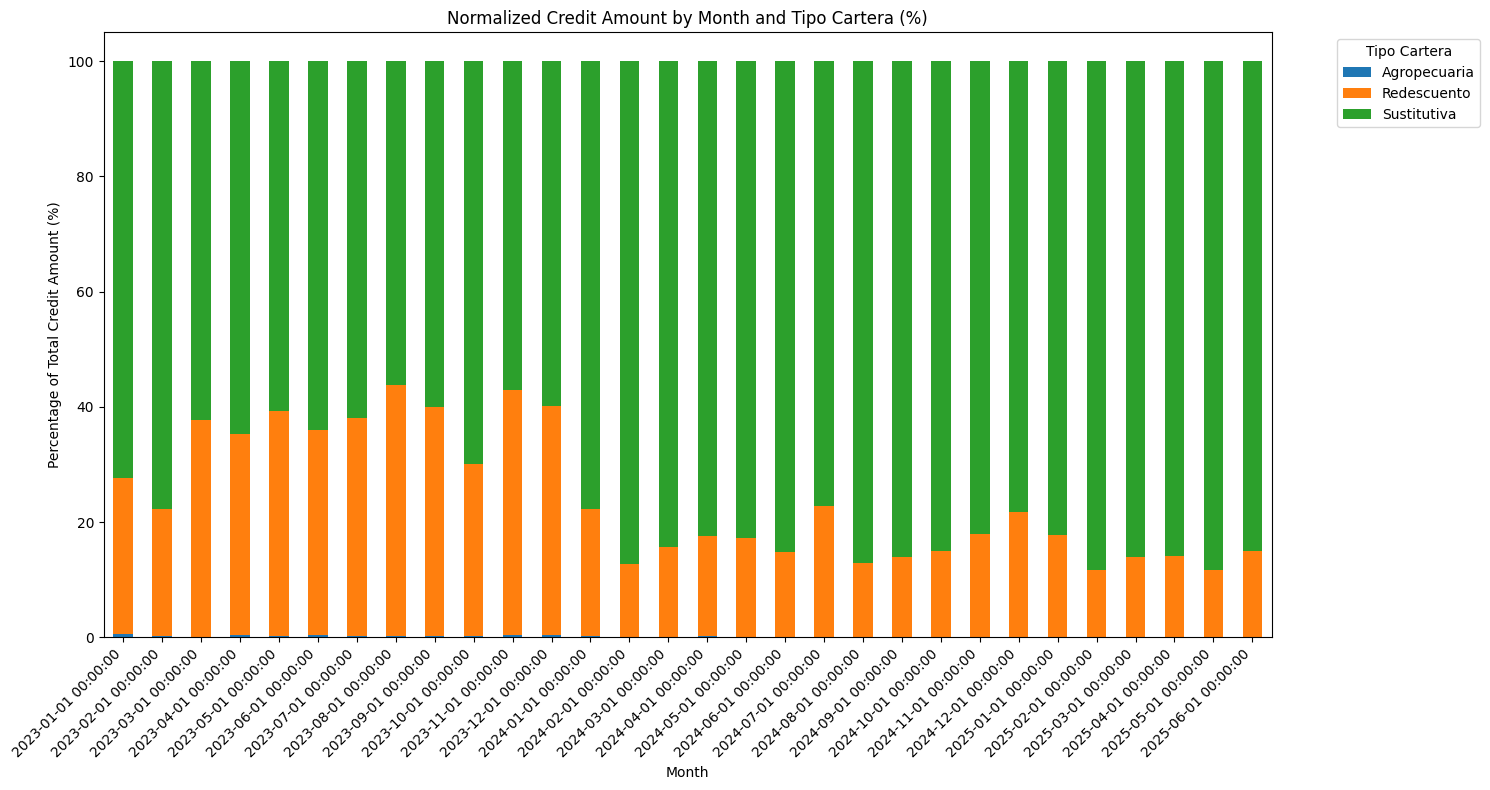

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_cartera'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_cartera', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Cartera (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Cartera', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Agrupación por semana SFC

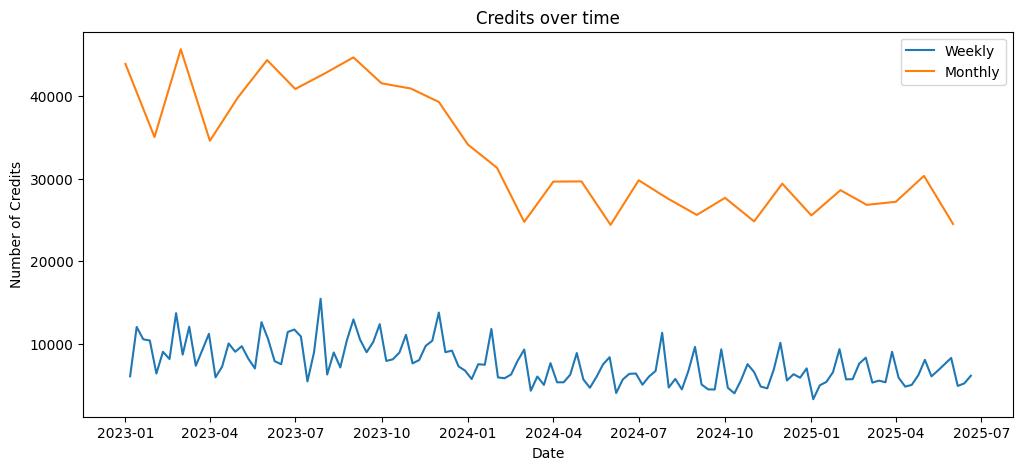

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- fechas ---
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# --- semana iniciando viernes ---
df_pandas['week'] = (
    df_pandas['fecha_credito']
    - pd.to_timedelta((df_pandas['fecha_credito'].dt.weekday - 4) % 7, unit='D')
).dt.floor('D')

# --- mes ---
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# --- agregaciones ---
weekly_credits = (
    df_pandas.groupby('week')['id_credito']
    .count()
    .sort_index()
)

monthly_credits = (
    df_pandas.groupby('month')['id_credito']
    .count()
    .sort_index()
)

# opcional: quitar semanas incompletas
weekly_credits = weekly_credits.iloc[1:-1]

# --- plot ---
plt.figure(figsize=(12,5))
plt.plot(weekly_credits.index, weekly_credits.values, label='Weekly')
plt.plot(monthly_credits.index, monthly_credits.values, label='Monthly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Number of Credits')
plt.title('Credits over time')
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
weekly_credits

,id_credito
week,
2023-01-06,6085
2023-01-13,12050
2023-01-20,10561
2023-01-27,10414
2023-02-03,6421
2023-02-10,9044
2023-02-17,8176
2023-02-24,13717
2023-03-03,8711


# Clasificación de créditos

In [ ]:
df_pandas.head(5)

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,linea_credito,cadena,eslabon_cadena,valor_credito,valor_inversion,plazo,periodo_gracia,cuotas,cuotas_capital,tasa_indexacion,periodicidad_tasa_indexacion,puntos_adicionales,garantia_fag,nombre_programa,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new,week,month
0,2350103751,2023-01-05,5887,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253050,Inversión,Ganaderia Leche,Producción,18000000.0,18000000.0,84,2,14,12,IBR,Semestral,4.7,True,IBR CREDITO ORDINARIO,False,0,True,5,ANTIOQUIA,YARUMAL,Urbano,12.869376,17.917881,17.180,2022-12-30,2023-01-01
1,2350127280,2023-01-30,52083,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,900001,Capital de Trabajo,Artesanias,Comercialización,12000000.0,12000000.0,36,0,12,12,IBR,Trimestral,4.7,True,IBR CREDITO ORDINARIO,False,0,False,52,NARIÑO,BELÉN,Urbano,12.633951,17.861196,16.776,2023-01-27,2023-01-01
2,2302529983,2023-01-30,25126,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NaN,408011,Capital de Trabajo,Avicultura,Producción,80000000.0,80000000.0,36,0,36,36,IBR,Mensual,9.5,True,IBR CREDITO ORDINARIO,False,0,True,25,CUNDINAMARCA,CAJICÁ,Urbano,12.547581,23.603404,21.379,2023-01-27,2023-01-01
3,2350117950,2023-01-20,68245,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253000,Inversión,Ganado DP,Producción,30000000.0,30000000.0,84,2,14,12,IBR,Semestral,4.7,True,IBR CREDITO ORDINARIO,False,0,True,68,SANTANDER,EL GUACAMAYO,Rural,12.827946,17.875535,17.141,2023-01-20,2023-01-01
4,2350104346,2023-01-05,41006,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,347050,Inversión,Café,Producción,10000000.0,10000000.0,83,8,14,6,IBR,Semestral,4.7,True,IBR CREDITO ORDINARIO,False,0,False,41,HUILA,ACEVEDO,Rural,12.869376,17.917881,17.180,2022-12-30,2023-01-01


In [ ]:
df = df_pandas[df_pandas['linea_credito'] != 'Normalización de Cartera'].copy()

In [ ]:
df['nombre_programa'].value_counts().head(20)

,count
nombre_programa,
IBR CREDITO ORDINARIO,505935
IBR MICROCREDITO AGROPECUARIO Y RURAL,105628
IBR TARJETA AGROPECUARIA,104547
IBR FINANCIACIÓN PROYECTOS EJECUTADOS POBLACIÓN EN SITUACIÓN ESPECIAL,76909
IBR LEC 2024 DESARROLLO PRODUCTIVO N2,45342
IBR LEC 2023 DESARROLLO PRODUCTIVO,41017
IBR LEC 2023 MUJER RURAL,19267
IBR MICROCREDITO GLOBAL,14138
IBR LEASING FINANCIERO,8979


In [ ]:
df['linea_credito'].value_counts().head(20)


,count
linea_credito,
Inversión,498000
Capital de Trabajo,496954


In [ ]:
df['tipo_productor'].value_counts()

,count
tipo_productor,
Pequeño ppib,599707
Pequeño,196173
Mediano,138123
Grande,60951


In [ ]:
df['tipo_beneficiario'].value_counts().head(20)

,count
tipo_beneficiario,
Pequeño productor de ingresos bajos,367966
Mediano productor,130339
Mujer rural ppib,109844
Microempresario pequeño,107894
Desplazado ppib,81467
Pequeño productor,68407
Grande productor,60336
Joven rural ppib,21522
Víctimas conflicto armado ppib,6310


In [ ]:
import numpy as np
import pandas as pd

UVB_PESOS = 12110  # AJUSTAR por año

POPULAR_MAX = 712 * UVB_PESOS
MICRO_MAX = 2968 * UVB_PESOS


def clasificar_credito(row):
    tb = str(row['tipo_beneficiario']).lower()
    tp = str(row['tipo_productor']).lower()
    monto = row['valor_credito']

    # -------------------------
    # NIVEL 1: determinístico
    # -------------------------
    if 'microempresario popular ppib' in tb:
        return 'popular_productivo_rural'

    # -------------------------
    # NIVEL 2: fuerte
    # -------------------------
    if 'microempresario' in tb and 'ppib' in tb and monto <= POPULAR_MAX:
        return 'popular_productivo_rural'

    # -------------------------
    # NIVEL 3: proxy
    # -------------------------
    if 'ppib' in tp and monto <= POPULAR_MAX:
        return 'popular_productivo_rural'

    # -------------------------
    # NIVEL 4: micro no popular
    # -------------------------
    if 'microempresario' in tb and monto <= MICRO_MAX:
        return 'productivo_rural'

    # -------------------------
    # NIVEL 5: default
    # -------------------------
    return 'productivo_rural'


df['clasificacion_credito'] = df.apply(clasificar_credito, axis=1)

In [ ]:
df["clasificacion_credito"].value_counts(dropna=False)

,count
clasificacion_credito,
productivo_rural,785901
popular_productivo_rural,209053


In [ ]:
df.groupby('clasificacion_credito')['valor_credito'].describe()

,count,mean,std,min,25%,50%,75%,max
clasificacion_credito,,,,,,,,
popular_productivo_rural,209053.0,4.938915e+06,1.989017e+06,2000.0,3200000.0,5000000.0,6530000.0,8.622000e+06
productivo_rural,785901.0,9.487730e+07,1.263038e+09,1.0,10000000.0,15000000.0,26000000.0,2.500000e+11


In [ ]:
df.groupby(['clasificacion_credito','garantia_fag'])['tasa_credito'].describe()

count       mean        std  \
clasificacion_credito    garantia_fag                                   
popular_productivo_rural False          15556.0  32.365637  26.301451   
                         True          193497.0  14.305769   3.614091   
productivo_rural         False         287374.0  32.207415  24.174630   
                         True          498527.0  17.753930  15.119656   

                                            min        25%        50%  \
clasificacion_credito    garantia_fag                                   
popular_productivo_rural False         0.659082  15.802349  19.331143   
                         True          0.000000  13.784889  15.261696   
productivo_rural         False         0.000000  17.260633  20.011395   
                         True          0.000000  13.466169  15.311002   

                                             75%         max  
clasificacion_credito    garantia_fag                         
popular_productivo_rural False         40.119313  100.121391  
                         True          16.025212   42.592700  
productivo_rural         False         58.171200   97.401612  
                         True          16.805299   96.441288

In [ ]:
df.groupby(['clasificacion_credito','garantia_fag'])['puntos_adicionales'].describe()

count       mean        std    min  \
clasificacion_credito    garantia_fag                                          
popular_productivo_rural False          15556.0  16.981332  19.008078  -8.10   
                         True          193497.0   2.717390   3.400963 -12.00   
productivo_rural         False         287374.0  15.742888  16.690331 -10.77   
                         True          498527.0   5.416826  10.648299 -12.00   

                                       25%  50%     75%    max  
clasificacion_credito    garantia_fag                           
popular_productivo_rural False         5.7  6.5  25.200  62.45  
                         True          1.9  2.6   4.800  25.20  
productivo_rural         False         5.7  7.0  34.405  58.08  
                         True          1.9  2.7   6.700  57.39

In [ ]:
df.groupby(['clasificacion_credito', 'tipo_productor']).size()

clasificacion_credito     tipo_productor
popular_productivo_rural  Pequeño ppib      209053
productivo_rural          Grande             60951
                          Mediano           138123
                          Pequeño           196173
                          Pequeño ppib      390654
dtype: int64

In [ ]:
res = (
    df
    .assign(valor_fag=lambda x: x['valor_credito'] * x['garantia_fag'])
    .groupby('clasificacion_credito')
    .agg(
        total=('valor_credito', 'sum'),
        con_fag=('valor_fag', 'sum')
    )
    .reset_index()
)

res['pct_fag'] = 100 * res['con_fag'] / res['total']
res

,clasificacion_credito,total,con_fag,pct_fag
0,popular_productivo_rural,1.032495e+12,9.728321e+11,94.221476
1,productivo_rural,7.456417e+13,1.239582e+13,16.624362


In [ ]:
(
    df.groupby(["clasificacion_credito", "tipo_productor"])
      .size()
      .reset_index(name="n")
      .sort_values(["clasificacion_credito", "n"], ascending=[True, False])
)

,clasificacion_credito,tipo_productor,n
0,popular_productivo_rural,Pequeño ppib,209053
4,productivo_rural,Pequeño ppib,390654
3,productivo_rural,Pequeño,196173
2,productivo_rural,Mediano,138123
1,productivo_rural,Grande,60951


In [ ]:
res_fag_n = (
    df.groupby("clasificacion_credito", dropna=False)
      .agg(
          n_creditos=("id_credito", "count"),
          pct_fag=("garantia_fag", "mean")
      )
      .reset_index()
)

res_fag_n["pct_fag"] = 100 * res_fag_n["pct_fag"]
res_fag_n

,clasificacion_credito,n_creditos,pct_fag
0,popular_productivo_rural,209053,92.558825
1,productivo_rural,785901,63.433817
